[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.2_batch_size_and_throughput/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.2_batch_size_and_throughput/lab.ipynb)

# Lab 2.2: Batch Size and Throughput

Explore the throughput-latency tradeoff as you change batch size.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# GPU and model parameters (A100 80GB)
bandwidth_gbs = 2039        # HBM bandwidth in GB/s
model_size_gb = 14.5        # Model weights in GB (7B params in fp16)
kv_per_token_mb = 2         # KV cache per token in MB

# Batch sizes to evaluate
batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64, 128])

## Throughput vs Batch Size

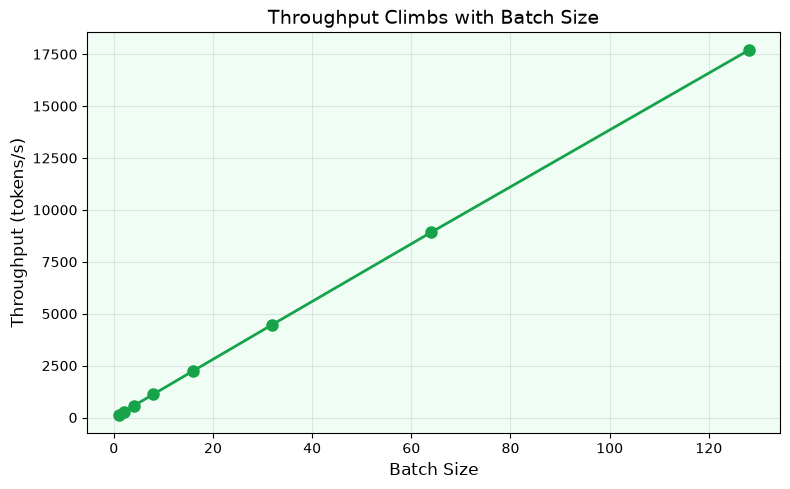

In [18]:
# Throughput model: more batches share the weight-load cost
# Time to load weights once (shared across batch)
weight_load_time_ms = (model_size_gb / bandwidth_gbs) * 1000  # ~7.1ms

# KV cache read time scales with batch size
kv_read_time_ms = (batch_sizes * kv_per_token_mb / 1000) / bandwidth_gbs * 1000

# Total time per step = weight load + KV reads
step_time_ms = weight_load_time_ms + kv_read_time_ms

# Throughput = tokens generated per second (one token per batch element per step)
throughput = batch_sizes / (step_time_ms / 1000)

# Plot throughput vs batch size
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(batch_sizes, throughput, 'o-', color='#16a34a', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size', fontsize=12)
ax.set_ylabel('Throughput (tokens/s)', fontsize=12)
ax.set_title('Throughput Climbs with Batch Size', fontsize=14)
ax.set_facecolor('#f0fdf4')  # pastel green background
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ITL (Latency) vs Batch Size

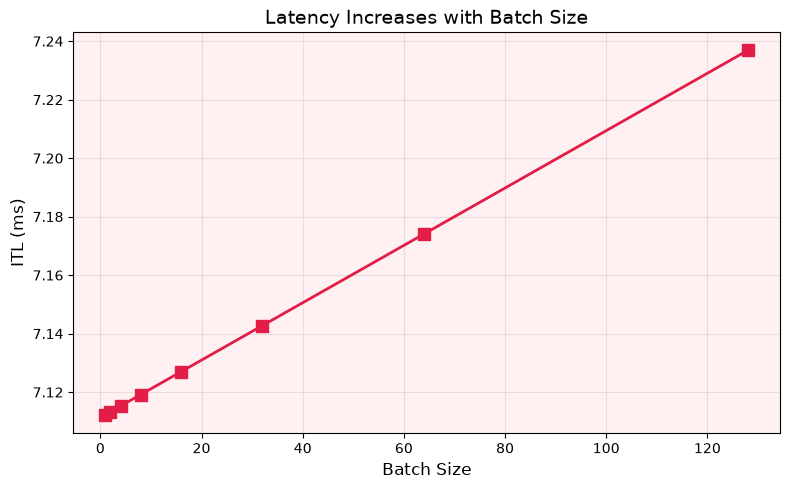

In [19]:
# Inter-token latency: each token waits for the full step to complete
# ITL = step_time (weight load is fixed, KV reads grow with batch)
itl_ms = step_time_ms.copy()

# Plot ITL vs batch size
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(batch_sizes, itl_ms, 's-', color='#e11d48', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size', fontsize=12)
ax.set_ylabel('ITL (ms)', fontsize=12)
ax.set_title('Latency Increases with Batch Size', fontsize=14)
ax.set_facecolor('#fff1f2')  # pastel rose background
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## The Sweet Spot: Both on One Chart

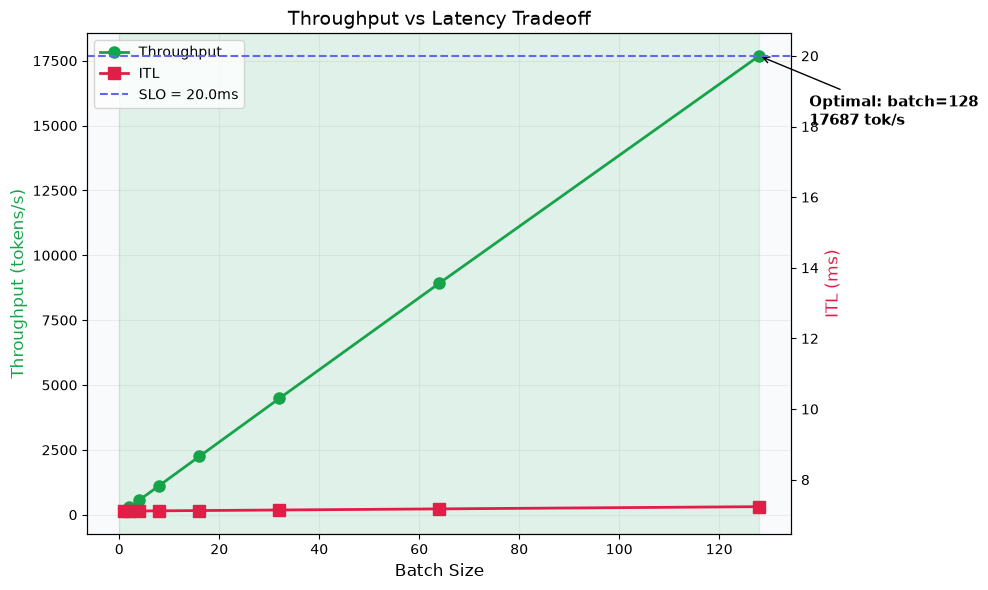


  RECOMMENDATION
  SLO constraint: ITL < 20.0ms
  Optimal batch size: 128
  Throughput at optimal: 17687 tokens/s
  ITL at optimal: 7.2ms


In [20]:
# SLO constraint: ITL must stay below 20ms
slo_itl_ms = 20.0

# Dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Left axis: throughput (green)
ln1 = ax1.plot(batch_sizes, throughput, 'o-', color='#16a34a', linewidth=2, markersize=8, label='Throughput')
ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel('Throughput (tokens/s)', fontsize=12, color='#16a34a')

# Right axis: ITL (rose)
ln2 = ax2.plot(batch_sizes, itl_ms, 's-', color='#e11d48', linewidth=2, markersize=8, label='ITL')
ax2.set_ylabel('ITL (ms)', fontsize=12, color='#e11d48')

# SLO horizontal line
ln3 = ax2.axhline(y=slo_itl_ms, color='#6366f1', linestyle='--', linewidth=1.5, label=f'SLO = {slo_itl_ms}ms')

# Shade the region where SLO is met (ITL < threshold)
slo_met = itl_ms <= slo_itl_ms
if slo_met.any():
    # Find max batch that meets SLO
    max_slo_batch = batch_sizes[slo_met][-1]
    ax1.axvspan(0, max_slo_batch, alpha=0.1, color='#16a34a', label='SLO met')
    # Optimal = highest throughput within SLO
    optimal_idx = np.where(slo_met)[0][-1]
    optimal_batch = batch_sizes[optimal_idx]
    optimal_tput = throughput[optimal_idx]
    # Annotate the optimal point
    ax1.annotate(f'Optimal: batch={optimal_batch}\n{optimal_tput:.0f} tok/s',
                 xy=(optimal_batch, optimal_tput),
                 xytext=(optimal_batch + 10, optimal_tput * 0.85),
                 fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#000'))

# Legend
lines = ln1 + ln2 + [ln3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

ax1.set_title('Throughput vs Latency Tradeoff', fontsize=14)
ax1.set_facecolor('#f8fafc')
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Print recommendation
print(f"\n{'='*50}")
print(f"  RECOMMENDATION")
print(f"  SLO constraint: ITL < {slo_itl_ms}ms")
print(f"  Optimal batch size: {optimal_batch}")
print(f"  Throughput at optimal: {optimal_tput:.0f} tokens/s")
print(f"  ITL at optimal: {itl_ms[optimal_idx]:.1f}ms")
print(f"{'='*50}")

## Key Takeaway

Maximum throughput isn't always the best operating point. Your SLO (latency budget)
determines the real batch size limit. Beyond that limit, you're violating user-facing
latency guarantees just to squeeze out more tokens/s that nobody can use in time.